# Exploration of datasets
## PAN 2023

In [1]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization import datasets

In [2]:
pan23 = datasets.Pan23Visualization()
ds_pan = pan23.load_dataset()
labels = ds_pan['same']
display(ds_pan.head())

,id,discourse_types,pair,same,authors
0,a0e656a3-955e-44f6-b5b3-dfd6e360a962,"[email, speech_transcription]",[I think I have decided with regards to the <t...,True,"[en_7, en_7]"
1,c42efa75-f418-4fac-80ca-4d0982704d25,"[email, speech_transcription]","[Dear <addr10_NN>, <nl><nl>If I was to go with...",True,"[en_31, en_31]"
2,a3a6745f-af62-4889-af49-93ec88594142,"[interview, email]","[So, erm, so I’m, erm, I’m actually from <cou...",True,"[en_88, en_88]"
3,244235f3-4647-4ed3-b078-60a2ea2850b7,"[email, speech_transcription]","[Hi <addr2_FN><nl><nl>This is my picture, that...",False,"[en_27, en_38]"
4,d410b3f0-b331-48ab-a524-c29ed1d487a2,"[interview, email]","[Oh, okay. Erm, well, I think of myself as kin...",False,"[en_87, en_32]"


In [3]:
labels.value_counts()

same
True     4418
False    4418
Name: count, dtype: int64

In [4]:
authors = ds_pan['authors'].tolist()
authors = [s for item in authors for s in item.flatten().tolist() if isinstance(item, np.ndarray)]

pairs = ds_pan['pair'].tolist()
texts = [s for item in pairs for s in item.flatten().tolist() if isinstance(item, np.ndarray)]

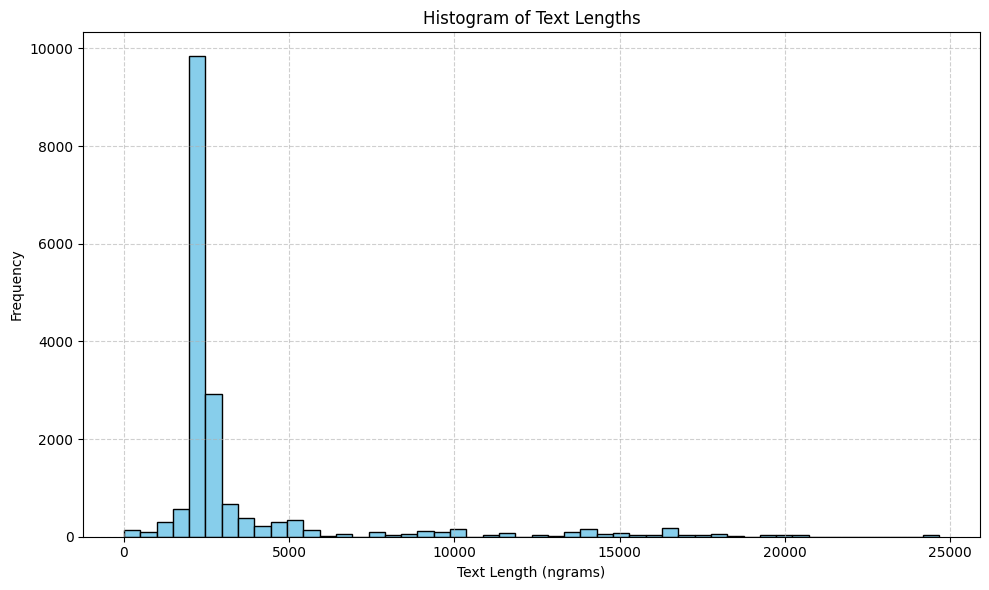

Average length (characters) per text: 3496.74


In [5]:
pan23.plot_text_length_histogram(pairs, bins=50)

In [6]:
def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())

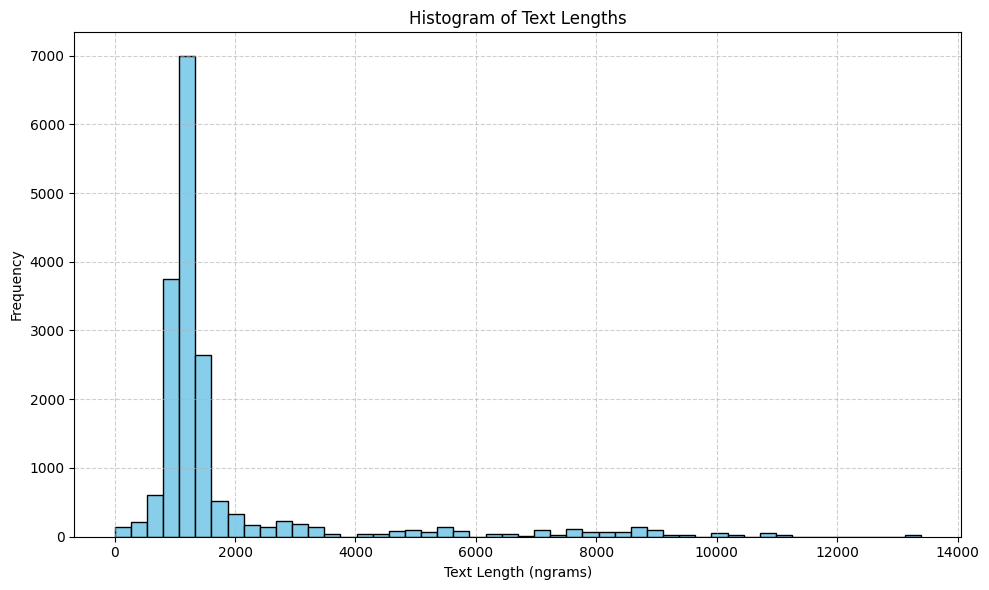

Average length (characters) per text: 1815.37


In [7]:
impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True, strict=True)
# list of lists of 4-grams
four_grams = [impostor_det.tokenize_char_ngrams(t, n=4, normalize_ws=True, space_free=True) for t in texts]
pan23.plot_text_length_histogram(four_grams, bins=50, preprocessed=False)

In [8]:
df_auth_text = pd.DataFrame({'author':authors, 'text':texts})

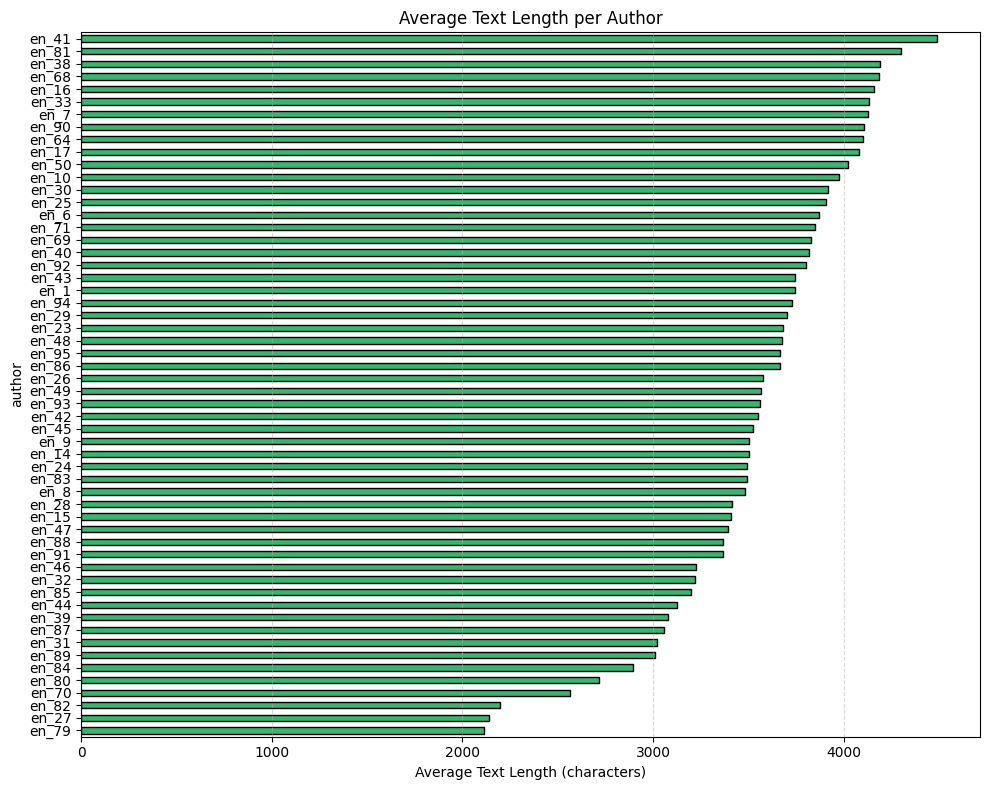

In [9]:
pan23.plot_avg_text_length_per_author(df_auth_text)

In [ ]:
pan23.plot_avg_text_length_per_author(df_auth_text, unit='ngrams')

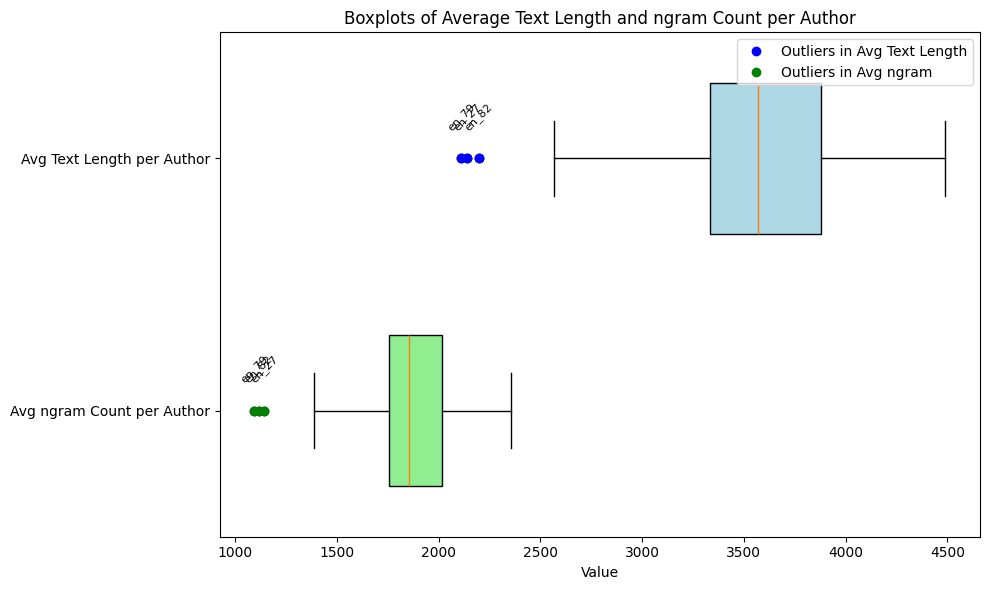

In [ ]:
pan23.boxplots_text_len_ngrams(df_auth_text)